## Demand Forecasting Model

### Import necessary library

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Load the Dataset

In [46]:
fitness_data = pd.read_excel("Cleaned_Preprocessed_Dataset_Yogeshwar Tribhuvan.xlsx")

### Dataset Information


In [47]:
fitness_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ActivitySiteID       3289 non-null   str           
 1   ActivityDescription  3289 non-null   str           
 2   BookingEndDate       3289 non-null   datetime64[us]
 3   BookingStartTime     3289 non-null   datetime64[us]
 4   MaxBookees           3289 non-null   int64         
 5   Number Booked        3289 non-null   int64         
 6   Price (INR)          3289 non-null   int64         
dtypes: datetime64[us](2), int64(3), str(2)
memory usage: 258.3 KB


In [48]:
fitness_data.head()

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,1900-01-01 14:45:00,25,12,499
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,1900-01-01 14:45:00,25,15,499
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,1900-01-01 14:45:00,25,14,499
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,1900-01-01 14:45:00,25,9,499
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,1900-01-01 14:45:00,25,7,499


### Prepare Daily Demand Data

In [49]:
demand_data = fitness_data.groupby("BookingEndDate")["Number Booked"].sum().reset_index()

demand_data

,BookingEndDate,Number Booked
0,2018-04-01,223
1,2018-04-02,296
2,2018-04-03,973
3,2018-04-04,905
4,2018-04-05,695
...,...,...
86,2018-06-26,826
87,2018-06-27,746
88,2018-06-28,571
89,2018-06-29,487


### Set Date as Index

In [50]:
demand_data.set_index("BookingEndDate", inplace=True)

demand_data.head()

,Number Booked
BookingEndDate,
2018-04-01,223
2018-04-02,296
2018-04-03,973
2018-04-04,905
2018-04-05,695


### Visualize Daily Demand

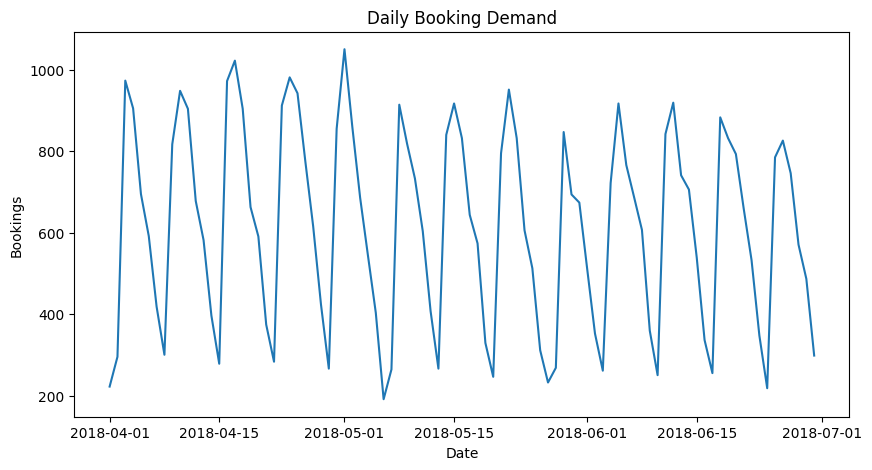

In [51]:
plt.figure(figsize=(10,5))

plt.plot(demand_data)

plt.title("Daily Booking Demand")

plt.xlabel("Date")

plt.ylabel("Bookings")

plt.show()

In [52]:
#Stationarity Test  Augmented Dickey-Fuller Test (ADF Test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(demand_data["Number Booked"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("The time series is Stationary")
else:
    print("The time series is Non-Stationary")

ADF Statistic : -2.2405174710828044
p-value : 0.19186983736946056
The time series is Non-Stationary


In [53]:
#Make data stationary
daily_diff = demand_data["Number Booked"].diff().dropna()

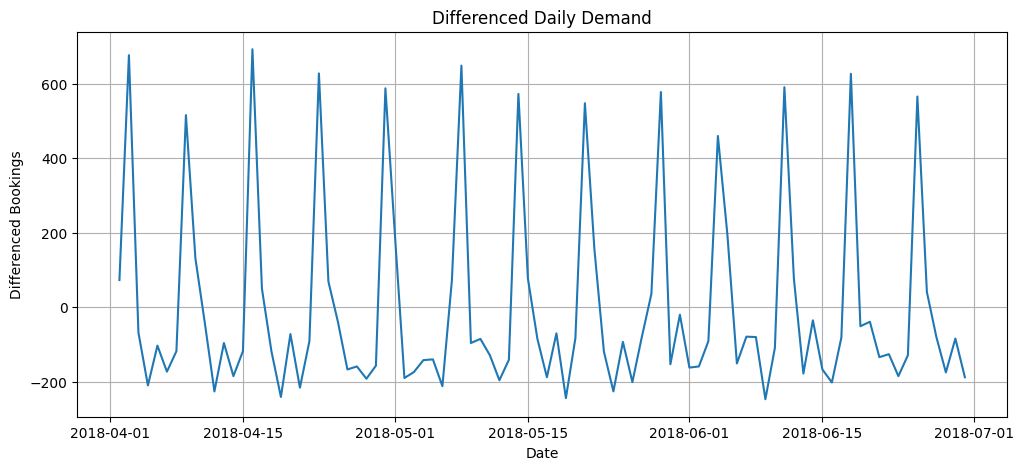

In [54]:
plt.figure(figsize=(12,5))

plt.plot(daily_diff)

plt.title("Differenced Daily Demand")

plt.xlabel("Date")

plt.ylabel("Differenced Bookings")

plt.grid(True)

plt.show()

In [55]:
#again check ADF
result = adfuller(daily_diff)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("The Differenced Series is Stationary")
else:
    print("Still Non-Stationary")

ADF Statistic : -15.163517675859847
p-value : 6.539992448387327e-28
The Differenced Series is Stationary


### Split Training and Testing Data

In [56]:
#Train-Test Split (Time Series)
train_size = int(len(demand_data) * 0.8)

train = demand_data["Number Booked"][:train_size]
test = demand_data["Number Booked"][train_size:]

print("Training Data :", len(train))
print("Testing Data :", len(test))

Training Data : 72
Testing Data : 19


### Train the ARIMA Model

In [57]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          Number Booked   No. Observations:                   72
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -465.300
Date:                Tue, 21 Jul 2026   AIC                            942.599
Time:                        21:45:19   BIC                            956.175
Sample:                    04-01-2018   HQIC                           947.998
                         - 06-11-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3207      0.115     -2.799      0.005      -0.545      -0.096
ar.L2         -0.5705      0.127     -4.500      0.000      -0.819      -0.322
ar.L3         -0.5029      0.164     -3.069      0.0

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### Forecast Future Demand

In [58]:
forecast = model_fit.forecast(steps=len(test))

### Evaluate Model Performance

In [62]:
mae = mean_absolute_error(test, forecast)

mse = mean_squared_error(test, forecast)

rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 74.36770222568252
MSE : 13781.930240031821
RMSE: 117.39646604575378


### Forecast Visualization

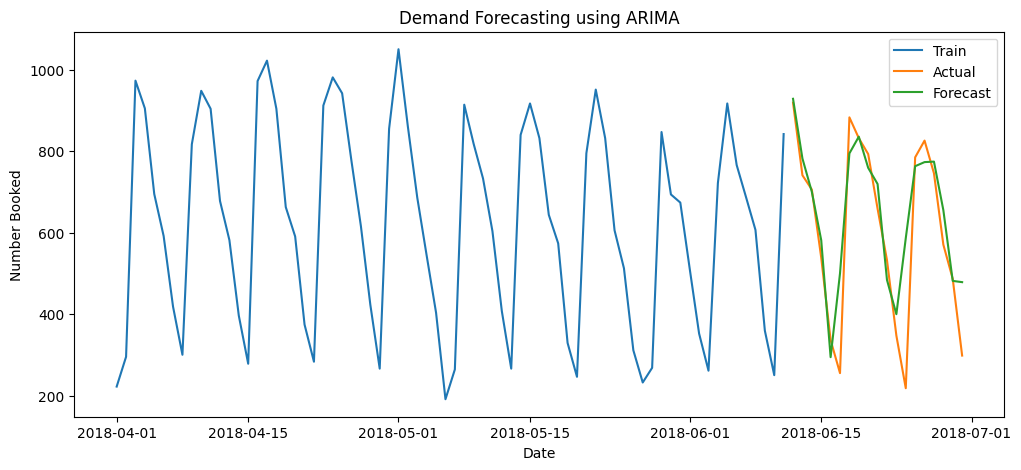

In [64]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Actual")

plt.plot(test.index, forecast, label="Forecast")

plt.legend()

plt.title("Demand Forecasting using ARIMA")

plt.xlabel("Date")

plt.ylabel("Number Booked")

plt.show()

### Actual vs Forecast Comparison

In [69]:
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

comparison

,Actual,Forecast
2018-06-12,919,928.460148
2018-06-13,741,782.076159
2018-06-14,706,700.484946
2018-06-15,539,581.893641
2018-06-16,337,295.114427
2018-06-17,256,500.583712
2018-06-18,883,794.612348
2018-06-19,832,835.654020
2018-06-20,793,759.170869
2018-06-21,659,719.552463


### Plot Actual and Forecasted Demand

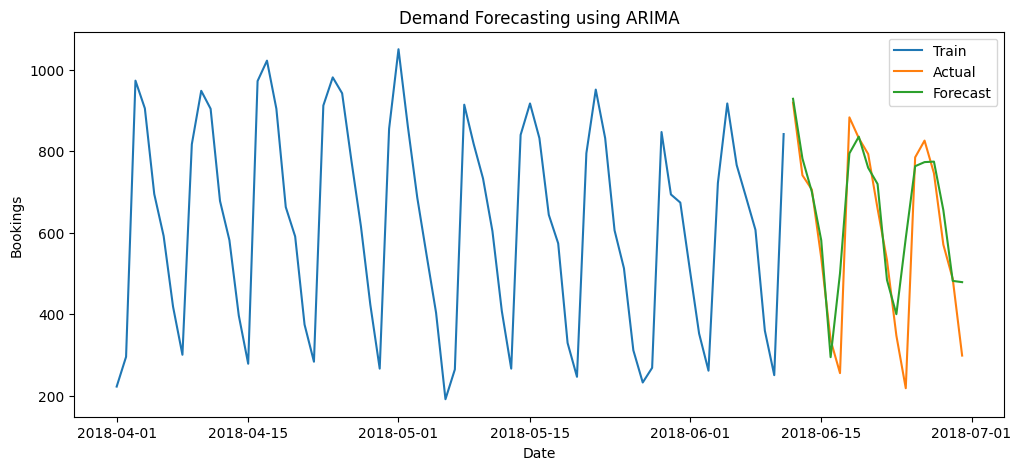

In [72]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("Demand Forecasting using ARIMA")
plt.xlabel("Date")
plt.ylabel("Bookings")
plt.legend()

plt.show()

### Complete Demand Forecast

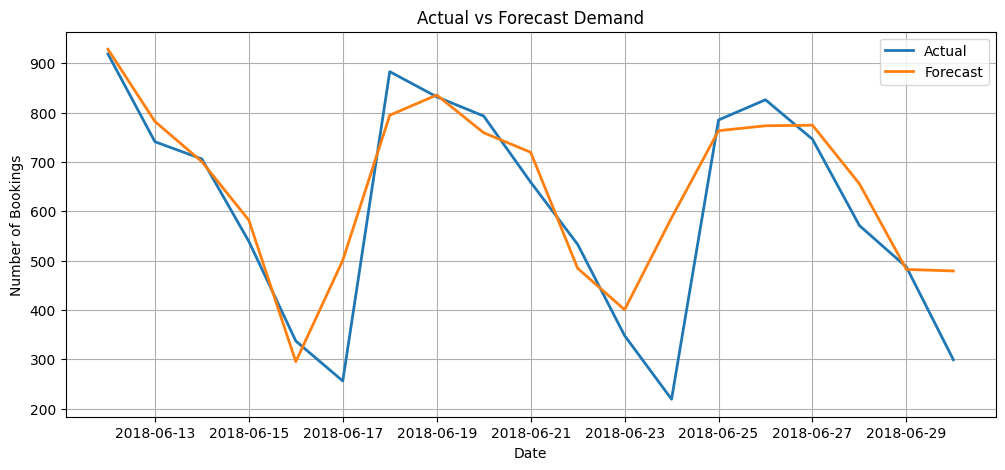

In [74]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, forecast, label="Forecast", linewidth=2)

plt.title("Actual vs Forecast Demand")
plt.xlabel("Date")
plt.ylabel("Number of Bookings")

plt.legend()
plt.grid(True)

plt.show()

### Display Evaluation Metrics

In [73]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 74.36770222568252
MSE : 13781.930240031821
RMSE: 117.39646604575378
